# Data Analysis

In [310]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels plotly


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [311]:
!pip install nbformat>=4.2.0


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [312]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
import plotly.express as px
import warnings
import unicodedata
import nbformat
import json
import re
import plotly.offline as pyo
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go  # or import plotly.express as px

In [313]:
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## Data Loading from Data Mart

In [314]:
DATABASE_FILE = 'ipai25.db' 

def load_table_from_db(db_path, table_name):
    """
    Connects to an SQLite database and loads a specified table into a Pandas DataFrame.
    Properly quotes table names to handle special characters.
    """
    conn = None
    try:
        conn = sqlite3.connect(db_path)
        query = f'SELECT * FROM "{table_name}";'
        df = pd.read_sql_query(query, conn)
        print(f"Successfully loaded '{table_name}' table. Shape: {df.shape}")
        return df
    except sqlite3.Error as e:
        print(f"Error loading table '{table_name}': {e}")
        return pd.DataFrame()
    finally:
        if conn:
            conn.close()

## Load each Data Mart table

In [315]:
print(f"Attempting to connect to database: {DATABASE_FILE}")

df_country_info = load_table_from_db(DATABASE_FILE, 'Country_information')
if not df_country_info.empty:
    print(f"Columns in df_country_info: {df_country_info.columns.tolist()}")
    print(f"Unique Countries in df_country_info: {df_country_info['Country'].nunique()}")

df_pm25_country = load_table_from_db(DATABASE_FILE, 'PM2.5-Country')
if not df_pm25_country.empty:
    print(f"Columns in df_pm25_country: {df_pm25_country.columns.tolist()}")
    print(f"Unique Countries in df_pm25_country: {df_pm25_country['Country'].nunique()}")
    print(f"Unique Years in df_pm25_country: {df_pm25_country['Year'].nunique()}")

df_forest_coverage = load_table_from_db(DATABASE_FILE, 'Forest_coverage')
if not df_forest_coverage.empty:
    print(f"Columns in df_forest_coverage: {df_forest_coverage.columns.tolist()}")
    print(f"Unique Countries in df_forest_coverage: {df_forest_coverage['Country'].nunique()}")
    print(f"Unique Years in df_forest_coverage: {df_forest_coverage['Year'].nunique()}")

df_traffic_list = load_table_from_db(DATABASE_FILE, 'Trafficlist')
if not df_traffic_list.empty:
    print(f"Columns in df_traffic_list: {df_traffic_list.columns.tolist()}")
    print(f"Unique Countries in df_traffic_list: {df_traffic_list['Country'].nunique()}")
    print(f"Unique Years in df_traffic_list: {df_traffic_list['Year'].nunique()}")

df_population_coverage = load_table_from_db(DATABASE_FILE, 'Population_coverage')
if not df_population_coverage.empty:
    print(f"Columns in df_population_coverage: {df_population_coverage.columns.tolist()}")
    print(f"Unique Countries in df_population_coverage: {df_population_coverage['Country'].nunique()}")
    print(f"Unique Years in df_population_coverage: {df_population_coverage['year'].nunique()} (original column name 'year')")


# Check if any dataframes are empty after loading
if df_country_info.empty or df_pm25_country.empty or df_forest_coverage.empty or df_traffic_list.empty or df_population_coverage.empty:
    print("\nOne or more essential data mart tables could not be loaded. Please check DATABASE_FILE path and table names.")
    print("Cannot proceed with analysis without the data. Please ensure your .db file is correct and tables exist.")
    exit()

print("\nData Loading Complete")

Attempting to connect to database: ipai25.db
Successfully loaded 'Country_information' table. Shape: (214, 5)
Columns in df_country_info: ['Country', 'Country Code', 'Capital', 'Continent', 'Area']
Unique Countries in df_country_info: 214
Successfully loaded 'PM2.5-Country' table. Shape: (6150, 4)
Columns in df_pm25_country: ['id', 'Country', 'Year', 'PM2.5']
Unique Countries in df_pm25_country: 246
Unique Years in df_pm25_country: 25
Successfully loaded 'Forest_coverage' table. Shape: (6634, 4)
Columns in df_forest_coverage: ['id', 'Country', 'Year', 'Forest_area']
Unique Countries in df_forest_coverage: 214
Unique Years in df_forest_coverage: 31
Successfully loaded 'Trafficlist' table. Shape: (182, 4)
Columns in df_traffic_list: ['Country', 'Rate[per 1000]', 'Vehicles', 'Year']
Unique Countries in df_traffic_list: 182
Unique Years in df_traffic_list: 14
Successfully loaded 'Population_coverage' table. Shape: (4163, 7)
Columns in df_population_coverage: ['Country', 'total_Population_m

## Data merging for analysis

In [316]:
print("\n Merging Data for Analysis")

# Clean column names by stripping whitespace/newline characters from all dataframes
for df_var in [df_country_info, df_pm25_country, df_forest_coverage, df_traffic_list, df_population_coverage]:
    df_var.columns = df_var.columns.str.strip()
    df_var.columns = df_var.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

# Standardize column names for merging and analysis & Renaming the columns
df_pm25_country = df_pm25_country.rename(columns={'PM2.5': 'PM25_ug_m3'})
df_population_coverage = df_population_coverage.rename(columns={
    'year': 'Year',
    'total_Population_million_people': 'Total_Population_million'
})
df_traffic_list = df_traffic_list.rename(columns={'Rate[per 1000]': 'Rate_per_1000'})

print("\nColumns after initial renames:")
print(f"df_country_info columns: {df_country_info.columns.tolist()}")
print(f"df_pm25_country columns: {df_pm25_country.columns.tolist()}")
print(f"df_forest_coverage columns: {df_forest_coverage.columns.tolist()}")
print(f"df_traffic_list columns: {df_traffic_list.columns.tolist()}")
print(f"df_population_coverage columns: {df_population_coverage.columns.tolist()}")


 Merging Data for Analysis

Columns after initial renames:
df_country_info columns: ['Country', 'Country Code', 'Capital', 'Continent', 'Area']
df_pm25_country columns: ['id', 'Country', 'Year', 'PM25_ug_m3']
df_forest_coverage columns: ['id', 'Country', 'Year', 'Forest_area']
df_traffic_list columns: ['Country', 'Rate_per_1000', 'Vehicles', 'Year']
df_population_coverage columns: ['Country', 'Total_Population_million', 'population_density', 'population_rank', 'population_coverage_perc', 'geographic_coverage_perc', 'Year']


In [317]:
# In depth cleaning for Country and Year values
def clean_merge_key_strings(df, column_name):
    """
    Cleans string columns used for merging by stripping whitespace,
    replacing non-breaking spaces, and normalizing Unicode.
    """
    if column_name in df.columns:
        df[column_name] = df[column_name].astype(str) \
                                         .str.strip() \
                                         .str.replace('\xa0', ' ') \
                                         .str.replace(r'\s+', ' ', regex=True) \
                                         .apply(lambda x: unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')) \
                                         .str.strip()
    return df

# Apply cleaning to 'Country' and 'Year' columns in all relevant dataframes
for df in [df_country_info, df_pm25_country, df_forest_coverage, df_traffic_list, df_population_coverage]:
    df = clean_merge_key_strings(df, 'Country')
    if 'Year' in df.columns: 
        df = clean_merge_key_strings(df, 'Year')
    elif 'year' in df.columns: 
        df = clean_merge_key_strings(df, 'year')

# Convert 'Year' columns to string for consistent merging
for df in [df_pm25_country, df_forest_coverage, df_traffic_list, df_population_coverage]:
    if 'Year' in df.columns:
        df['Year'] = df['Year'].astype(str)

In [318]:
# Merging on 'Country' which is common across all tables
df_analysis = pd.merge(df_pm25_country, df_country_info, on='Country', how='inner', suffixes=('_pm25', '_info'))
print(f"Shape after merge with Country_information: {df_analysis.shape}")
print(f"Columns after merge with Country_information: {df_analysis.columns.tolist()}")

# Merge with population data
df_analysis = pd.merge(df_analysis, df_population_coverage[['Country', 'Year', 'Total_Population_million', 'population_density', 'population_rank']],
                       on=['Country', 'Year'], how='left')
print(f"Shape after merge with Population_coverage: {df_analysis.shape}")
print(f"Columns after merge with Population_coverage: {df_analysis.columns.tolist()}")

# Merge with forest coverage data
df_analysis = pd.merge(df_analysis, df_forest_coverage[['Country', 'Year', 'Forest_area']],
                       on=['Country', 'Year'], how='left')
print(f"Shape after merge with Forest_coverage: {df_analysis.shape}")
print(f"Columns after merge with Forest_coverage: {df_analysis.columns.tolist()}")

# Merge with traffic data
df_analysis = pd.merge(df_analysis, df_traffic_list[['Country', 'Year', 'Vehicles', 'Rate_per_1000']],
                       on=['Country', 'Year'], how='left')
print(f"Shape after merge with Trafficlist: {df_analysis.shape}")
print(f"Columns after merge with Trafficlist: {df_analysis.columns.tolist()}")

Shape after merge with Country_information: (4525, 8)
Columns after merge with Country_information: ['id', 'Country', 'Year', 'PM25_ug_m3', 'Country Code', 'Capital', 'Continent', 'Area']
Shape after merge with Population_coverage: (4525, 11)
Columns after merge with Population_coverage: ['id', 'Country', 'Year', 'PM25_ug_m3', 'Country Code', 'Capital', 'Continent', 'Area', 'Total_Population_million', 'population_density', 'population_rank']
Shape after merge with Forest_coverage: (4525, 12)
Columns after merge with Forest_coverage: ['id', 'Country', 'Year', 'PM25_ug_m3', 'Country Code', 'Capital', 'Continent', 'Area', 'Total_Population_million', 'population_density', 'population_rank', 'Forest_area']
Shape after merge with Trafficlist: (4525, 14)
Columns after merge with Trafficlist: ['id', 'Country', 'Year', 'PM25_ug_m3', 'Country Code', 'Capital', 'Continent', 'Area', 'Total_Population_million', 'population_density', 'population_rank', 'Forest_area', 'Vehicles', 'Rate_per_1000']


## Data preprocessing and cleaning for analysis

In [319]:
# Ensure all key analytical columns are numeric and drop rows with NaNs in these columns
numeric_cols = [
    'PM25_ug_m3', 'Rate_per_1000', 'Total_Population_million',
    'Forest_area', 'Area', 'population_density'
]
for col in numeric_cols:
    if col in df_analysis.columns:
        df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

df_analysis = df_analysis.rename(columns={'Forest_area': 'forest_area_percent'})

df_analysis = df_analysis.rename(columns={
    'Area': 'Area_km2', 
    'Capital': 'capital', 
    'Continent': 'continent', 
    'population_density': 'population_density_calc' 
})

print("\nNaN counts before final dropna:")
cols_to_check_nan_global = [ 
    'PM25_ug_m3', 'Total_Population_million',
    'forest_area_percent', 'Area_km2', 'population_density_calc'
]
print(df_analysis[cols_to_check_nan_global].isnull().sum())

print("\nFinal Merged Analytical DataFrame Head (before local dropna):")
print(df_analysis.head())
print(f"\nFinal Merged DataFrame shape (before local dropna): {df_analysis.shape}")

if df_analysis.empty:
    print("The final analytical DataFrame is empty after merging. Cannot proceed with analysis.")
    exit() 


NaN counts before final dropna:
PM25_ug_m3                    0
Total_Population_million    362
forest_area_percent         394
Area_km2                      0
population_density_calc     362
dtype: int64

Final Merged Analytical DataFrame Head (before local dropna):
   id Country  Year  PM25_ug_m3 Country Code     capital      continent  \
0   2   Aruba  1998         9.5          ABW  Oranjestad  North America   
1   3   Aruba  1999        10.1          ABW  Oranjestad  North America   
2   4   Aruba  2000        10.2          ABW  Oranjestad  North America   
3   5   Aruba  2001        10.6          ABW  Oranjestad  North America   
4   6   Aruba  2002        10.5          ABW  Oranjestad  North America   

   Area_km2  Total_Population_million  population_density_calc  \
0       180                     0.088                 591.3611   
1       180                     0.088                 591.3611   
2       180                     0.088                 591.3611   
3       180     

## Debugging for Trafficlist

In [320]:
print("\nTraffic Data Coverage Check")
pm25_countries_years = set(df_pm25_country.apply(lambda row: (row['Country'], row['Year']), axis=1))
traffic_countries_years = set(df_traffic_list.apply(lambda row: (row['Country'], row['Year']), axis=1))

common_country_year_pairs = pm25_countries_years.intersection(traffic_countries_years)

print(f"\nNumber of unique (Country, Year) pairs in PM2.5-Country: {len(pm25_countries_years)}")
print(f"Number of unique (Country, Year) pairs in Trafficlist: {len(traffic_countries_years)}")
print(f"Number of common (Country, Year) pairs for merge: {len(common_country_year_pairs)}")

if len(common_country_year_pairs) == 0:
    print("WARNING: There are NO common (Country, Year) combinations between PM2.5-Country and Trafficlist.")
    print("This is why 'Rate_per_1000' and 'Vehicles' columns are entirely NaN after merging.")
    print("Hypothesis 1 analysis will be skipped due to lack of data.")
else:
    print("Common (Country, Year) pairs found. Analysis will proceed.")


Traffic Data Coverage Check

Number of unique (Country, Year) pairs in PM2.5-Country: 6150
Number of unique (Country, Year) pairs in Trafficlist: 182
Number of common (Country, Year) pairs for merge: 125
Common (Country, Year) pairs found. Analysis will proceed.


### Targeted Debugging - using India and 2015 as example

In [321]:
target_country = 'India'
target_year = '2015'

df_pm25_india_2015 = df_pm25_country[(df_pm25_country['Country'] == target_country) & (df_pm25_country['Year'] == str(target_year))]
print(f"\nData for '{target_country}' in '{target_year}' in df_pm25_country:")
print(df_pm25_india_2015)
print("Dtypes for df_pm25_country Country and Year columns:", df_pm25_country[['Country', 'Year']].dtypes)

if not df_pm25_india_2015.empty:
    print(f"Raw 'Country' value in df_pm25_country: {repr(df_pm25_india_2015['Country'].iloc[0])}")
    print(f"Raw 'Year' value in df_pm25_country: {repr(df_pm25_india_2015['Year'].iloc[0])}")

df_traffic_india_2015 = df_traffic_list[(df_traffic_list['Country'] == target_country) & (df_traffic_list['Year'] == str(target_year))]
print(f"\nData for '{target_country}' in '{target_year}' in df_traffic_list:")
print(df_traffic_india_2015)
print("Dtypes for df_traffic_list Country and Year columns:", df_traffic_list[['Country', 'Year']].dtypes)

if not df_traffic_india_2015.empty:
    print(f"Raw 'Country' value in df_traffic_list: {repr(df_traffic_india_2015['Country'].iloc[0])}")
    print(f"Raw 'Year' value in df_traffic_list: {repr(df_traffic_india_2015['Year'].iloc[0])}")

if not df_pm25_india_2015.empty and not df_traffic_india_2015.empty:
    print(f"\nBoth df_pm25_country and df_traffic_list contain data for '{target_country}' in '{target_year}'.")
    print("If still seeing NaN in df_analysis, the issue is likely due to subtle data differences in merge keys.")
else:
    print(f"\nOne or both source tables DO NOT contain data for '{target_country}' in '{target_year}' with exact matching 'Country' and 'Year' values.")
    print("This explains why the merged dataframe shows NaN for traffic data for this specific row.")



Data for 'India' in '2015' in df_pm25_country:
        id Country  Year  PM25_ug_m3
2517  2519   India  2015        50.6
Dtypes for df_pm25_country Country and Year columns: Country    object
Year       object
dtype: object
Raw 'Country' value in df_pm25_country: 'India'
Raw 'Year' value in df_pm25_country: '2015'

Data for 'India' in '2015' in df_traffic_list:
    Country Rate_per_1000     Vehicles  Year
120   India           158  210,023,289  2015
Dtypes for df_traffic_list Country and Year columns: Country    object
Year       object
dtype: object
Raw 'Country' value in df_traffic_list: 'India'
Raw 'Year' value in df_traffic_list: '2015'

Both df_pm25_country and df_traffic_list contain data for 'India' in '2015'.
If still seeing NaN in df_analysis, the issue is likely due to subtle data differences in merge keys.


### Example to search a specific country corresponding to particular year

In [322]:
country_to_search = 'Qatar'
year_to_search = '2016'

df_specific_row_data = df_analysis[
    (df_analysis['Country'] == country_to_search) & (df_analysis['Year'] == str(year_to_search))
]

if not df_specific_row_data.empty:
    print(f"\nData for {country_to_search} in {year_to_search}:")
    print(df_specific_row_data)
else:
    print(f"\nNo data found for {country_to_search} in {year_to_search}.")


Data for Qatar in 2016:
        id Country  Year  PM25_ug_m3 Country Code capital continent  Area_km2  \
3493  4545   Qatar  2016        94.8          QAT    Doha      Asia     11586   

      Total_Population_million  population_density_calc  population_rank  \
3493                     2.258                 232.6189            143.0   

      forest_area_percent   Vehicles  Rate_per_1000  
3493                  0.0  1,330,487          512.0  


### Checking for unique countries and years in df_analysis

In [323]:
print("\nUnique Countries and Years in Merged DataFrame (df_analysis)")

if not df_analysis.empty:
    unique_countries = df_analysis['Country'].unique().tolist()
    unique_years = df_analysis['Year'].unique().tolist()

    print(f"\nUnique Countries in df_analysis ({len(unique_countries)}):")
    print(unique_countries)

    print(f"\nUnique Years in df_analysis ({len(unique_years)}):")
    print(unique_years)
else:
    print("\ndf_analysis is empty, cannot list unique countries or years.")


Unique Countries and Years in Merged DataFrame (df_analysis)

Unique Countries in df_analysis (181):
['Aruba', 'Afghanistan', 'Angola', 'Albania', 'Andorra', 'United Arab Emirates', 'Argentina', 'Armenia', 'American Samoa', 'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh', 'Bulgaria', 'Bahrain', 'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bermuda', 'Bolivia', 'Brazil', 'Barbados', 'Bhutan', 'Botswana', 'Central African Republic', 'Canada', 'Switzerland', 'Chile', 'China', 'Cameroon', 'Colombia', 'Comoros', 'Costa Rica', 'Cuba', 'Cayman Islands', 'Cyprus', 'Czech Republic', 'Germany', 'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic', 'Algeria', 'Ecuador', 'Eritrea', 'Spain', 'Estonia', 'Ethiopia', 'Finland', 'Fiji', 'France', 'Faroe Islands', 'Gabon', 'United Kingdom', 'Georgia', 'Ghana', 'Gibraltar', 'Guinea', 'Guinea-Bissau', 'Equatorial Guinea', 'Greece', 'Grenada', 'Greenland', 'Guatemala', 'Guam', '

## Data Analysis - Hypothesis Testing

### Analysis 1: The influence of the number of vehicles on PM 2.5


Traffic Rate per 1000 & PM2.5
Pearson correlation between Vehicles Rate per 1000 and PM2.5: -0.41 (p-value: 0.000)


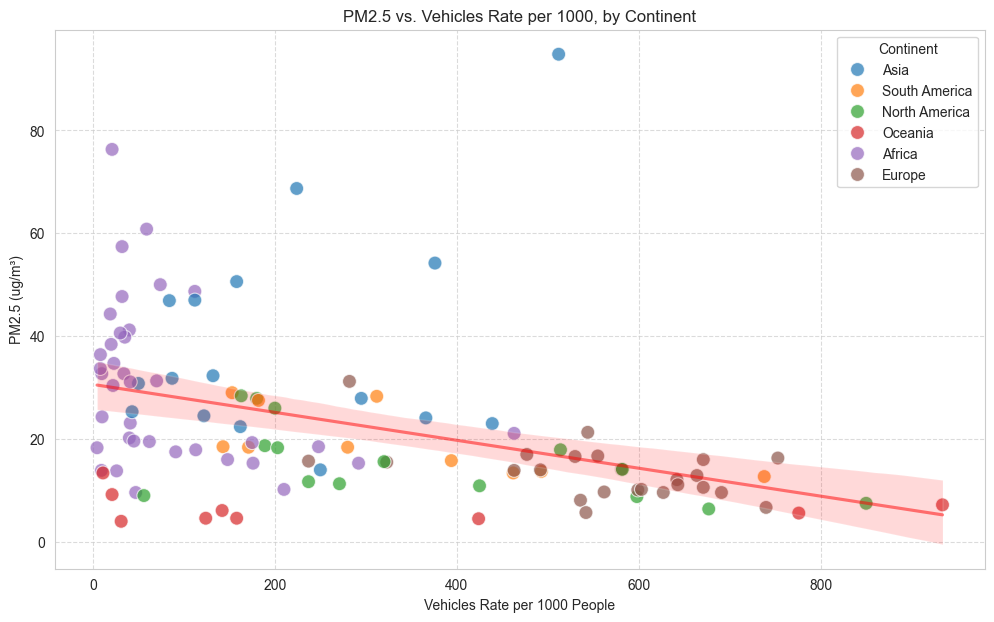


Regression Model Summary (PM25_ug_m3 ~ Rate_per_1000):
                            OLS Regression Results                            
Dep. Variable:             PM25_ug_m3   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     22.68
Date:                Sat, 31 May 2025   Prob (F-statistic):           5.94e-06
Time:                        18:07:30   Log-Likelihood:                -455.02
No. Observations:                 111   AIC:                             914.0
Df Residuals:                     109   BIC:                             919.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

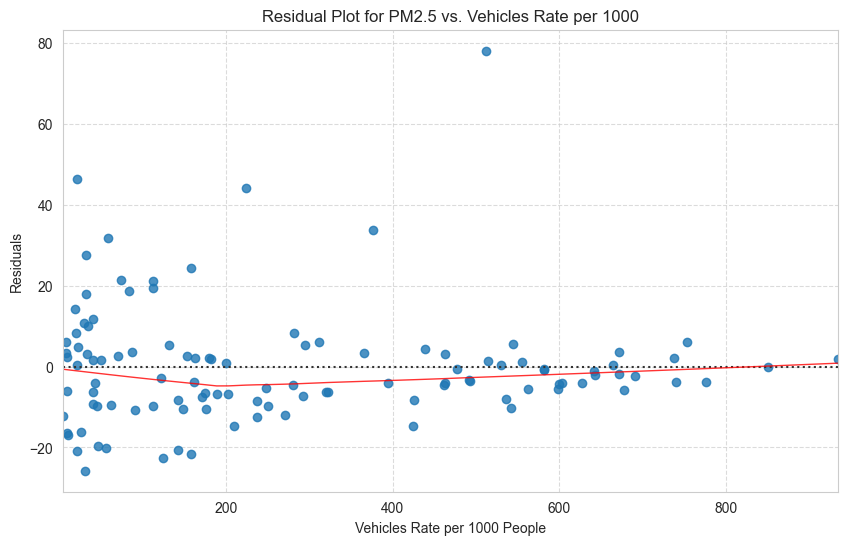

In [324]:
print("\nTraffic Rate per 1000 & PM2.5")

temp_df_h1 = df_analysis.dropna(subset=['Rate_per_1000', 'PM25_ug_m3'])
if temp_df_h1.empty:
    print("No common data points for 'Rate_per_1000' and 'PM25_ug_m3' after dropping NaNs for analysis.")
else:
    # 1. Correlation analysis
    correlation_h1, p_value_h1 = pearsonr(temp_df_h1['Rate_per_1000'], temp_df_h1['PM25_ug_m3'])
    print(f"Pearson correlation between Vehicles Rate per 1000 and PM2.5: {correlation_h1:.2f} (p-value: {p_value_h1:.3f})")

    # 2. Scatter Plot - Regression line
    plt.figure(figsize=(12, 7))
    sns.scatterplot(x='Rate_per_1000', y='PM25_ug_m3', hue='continent', data=temp_df_h1, s=100, alpha=0.7)
    sns.regplot(x='Rate_per_1000', y='PM25_ug_m3', data=temp_df_h1, scatter=False, color='red', line_kws={'alpha':0.5})
    plt.title('PM2.5 vs. Vehicles Rate per 1000, by Continent')
    plt.xlabel('Vehicles Rate per 1000 People')
    plt.ylabel('PM2.5 (ug/m³)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Continent')
    plt.show()

    # 3. Regression analysis
    model_h1 = smf.ols('PM25_ug_m3 ~ Rate_per_1000', data=temp_df_h1).fit()
    print("\nRegression Model Summary (PM25_ug_m3 ~ Rate_per_1000):")
    print(model_h1.summary())

    # 4. Residual plot
    plt.figure(figsize=(10, 6))
    sns.residplot(x='Rate_per_1000', y='PM25_ug_m3', data=temp_df_h1, lowess=True,
                  line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Residual Plot for PM2.5 vs. Vehicles Rate per 1000')
    plt.xlabel('Vehicles Rate per 1000 People')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Analysis 2: Influence of Population on PM2.5


Population & PM2.5


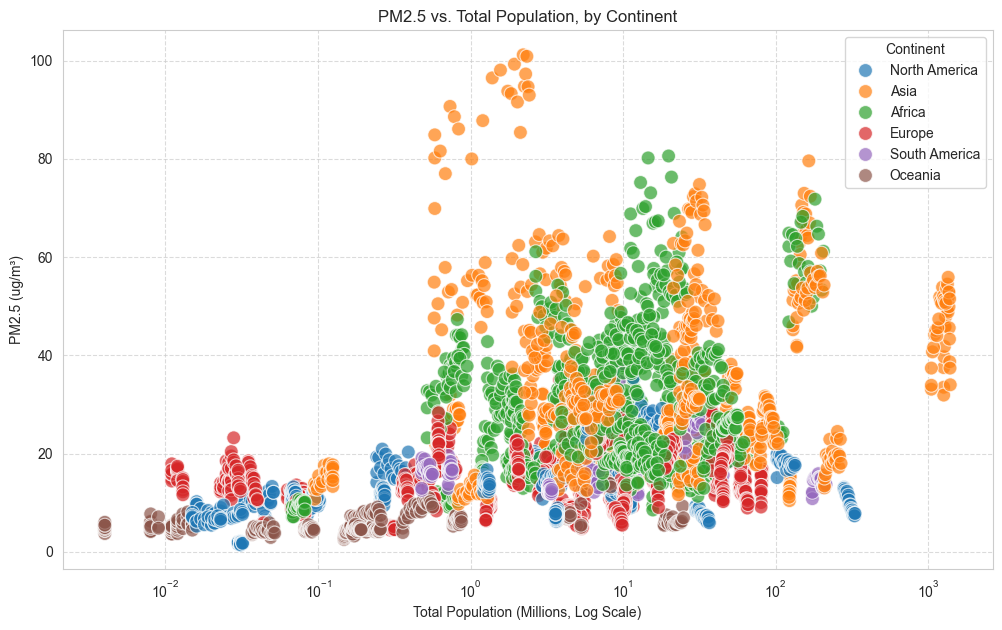

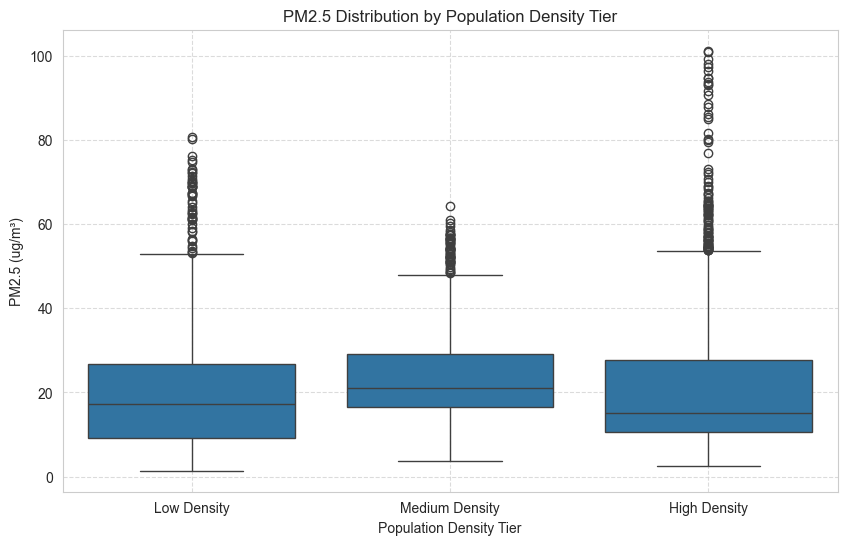

In [325]:
print("\nPopulation & PM2.5")


temp_df_h2 = df_analysis.dropna(subset=['Total_Population_million', 'population_density_calc', 'PM25_ug_m3'])
if temp_df_h2.empty:
    print("No common data points for population analysis after dropping NaNs for analysis.")
else:
    # 1. Scatter Plot Total Population (log scale)
    plt.figure(figsize=(12, 7))
    sns.scatterplot(x='Total_Population_million', y='PM25_ug_m3', hue='continent', data=temp_df_h2, s=100, alpha=0.7)
    plt.xscale('log') # Use log scale for population due to wider range
    plt.title('PM2.5 vs. Total Population, by Continent')
    plt.xlabel('Total Population (Millions, Log Scale)')
    plt.ylabel('PM2.5 (ug/m³)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Continent')
    plt.show()

    # Size of bubble by Area_km2, color by continent
    fig = px.scatter(temp_df_h2,
                     x='Total_Population_million',
                     y='PM25_ug_m3',
                     size='Area_km2',
                     color='continent', 
                     hover_name='Country', 
                     log_x=True, 
                     title='PM2.5 vs. Total Population (Bubble Chart, Interactive)',
                     labels={'Total_Population_million': 'Total Population (Millions)',
                             'PM25_ug_m3': 'PM25_ug_m3 (ug/m³)',
                             'Area_km2': 'Area (km²)'}
                    )
    fig.show()

    # Grouped Analysis by Population Density
    temp_df_h2_density = temp_df_h2.copy() 
    temp_df_h2_density['Population_Density_Tier'] = pd.qcut(temp_df_h2_density['population_density_calc'], q=3, labels=['Low Density', 'Medium Density', 'High Density'], duplicates='drop')

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Population_Density_Tier', y='PM25_ug_m3', data=temp_df_h2_density, order=['Low Density', 'Medium Density', 'High Density'])
    plt.title('PM2.5 Distribution by Population Density Tier')
    plt.xlabel('Population Density Tier')
    plt.ylabel('PM2.5 (ug/m³)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Analysis 3: Influence of Forest coverage on PM2.5


Forest Coverage & PM2.5
Pearson correlation between Forest Area Percent and PM2.5: -0.28 (p-value: 0.000)


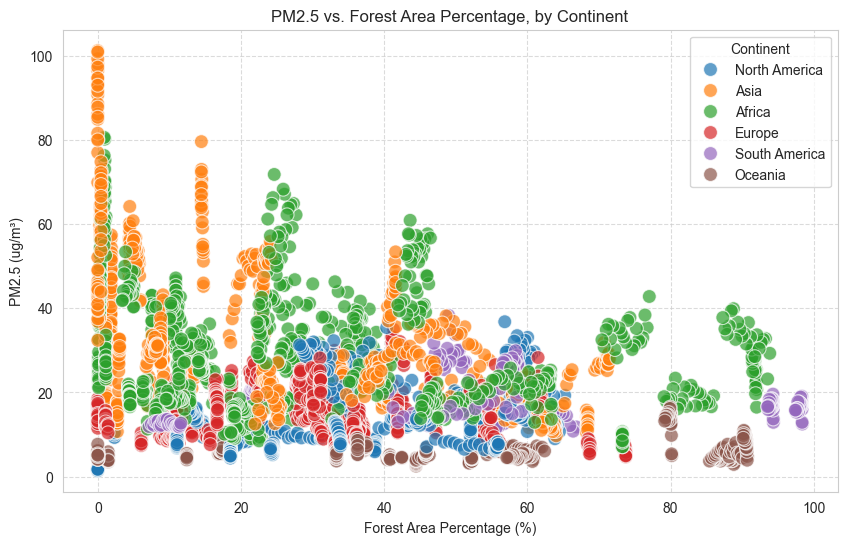

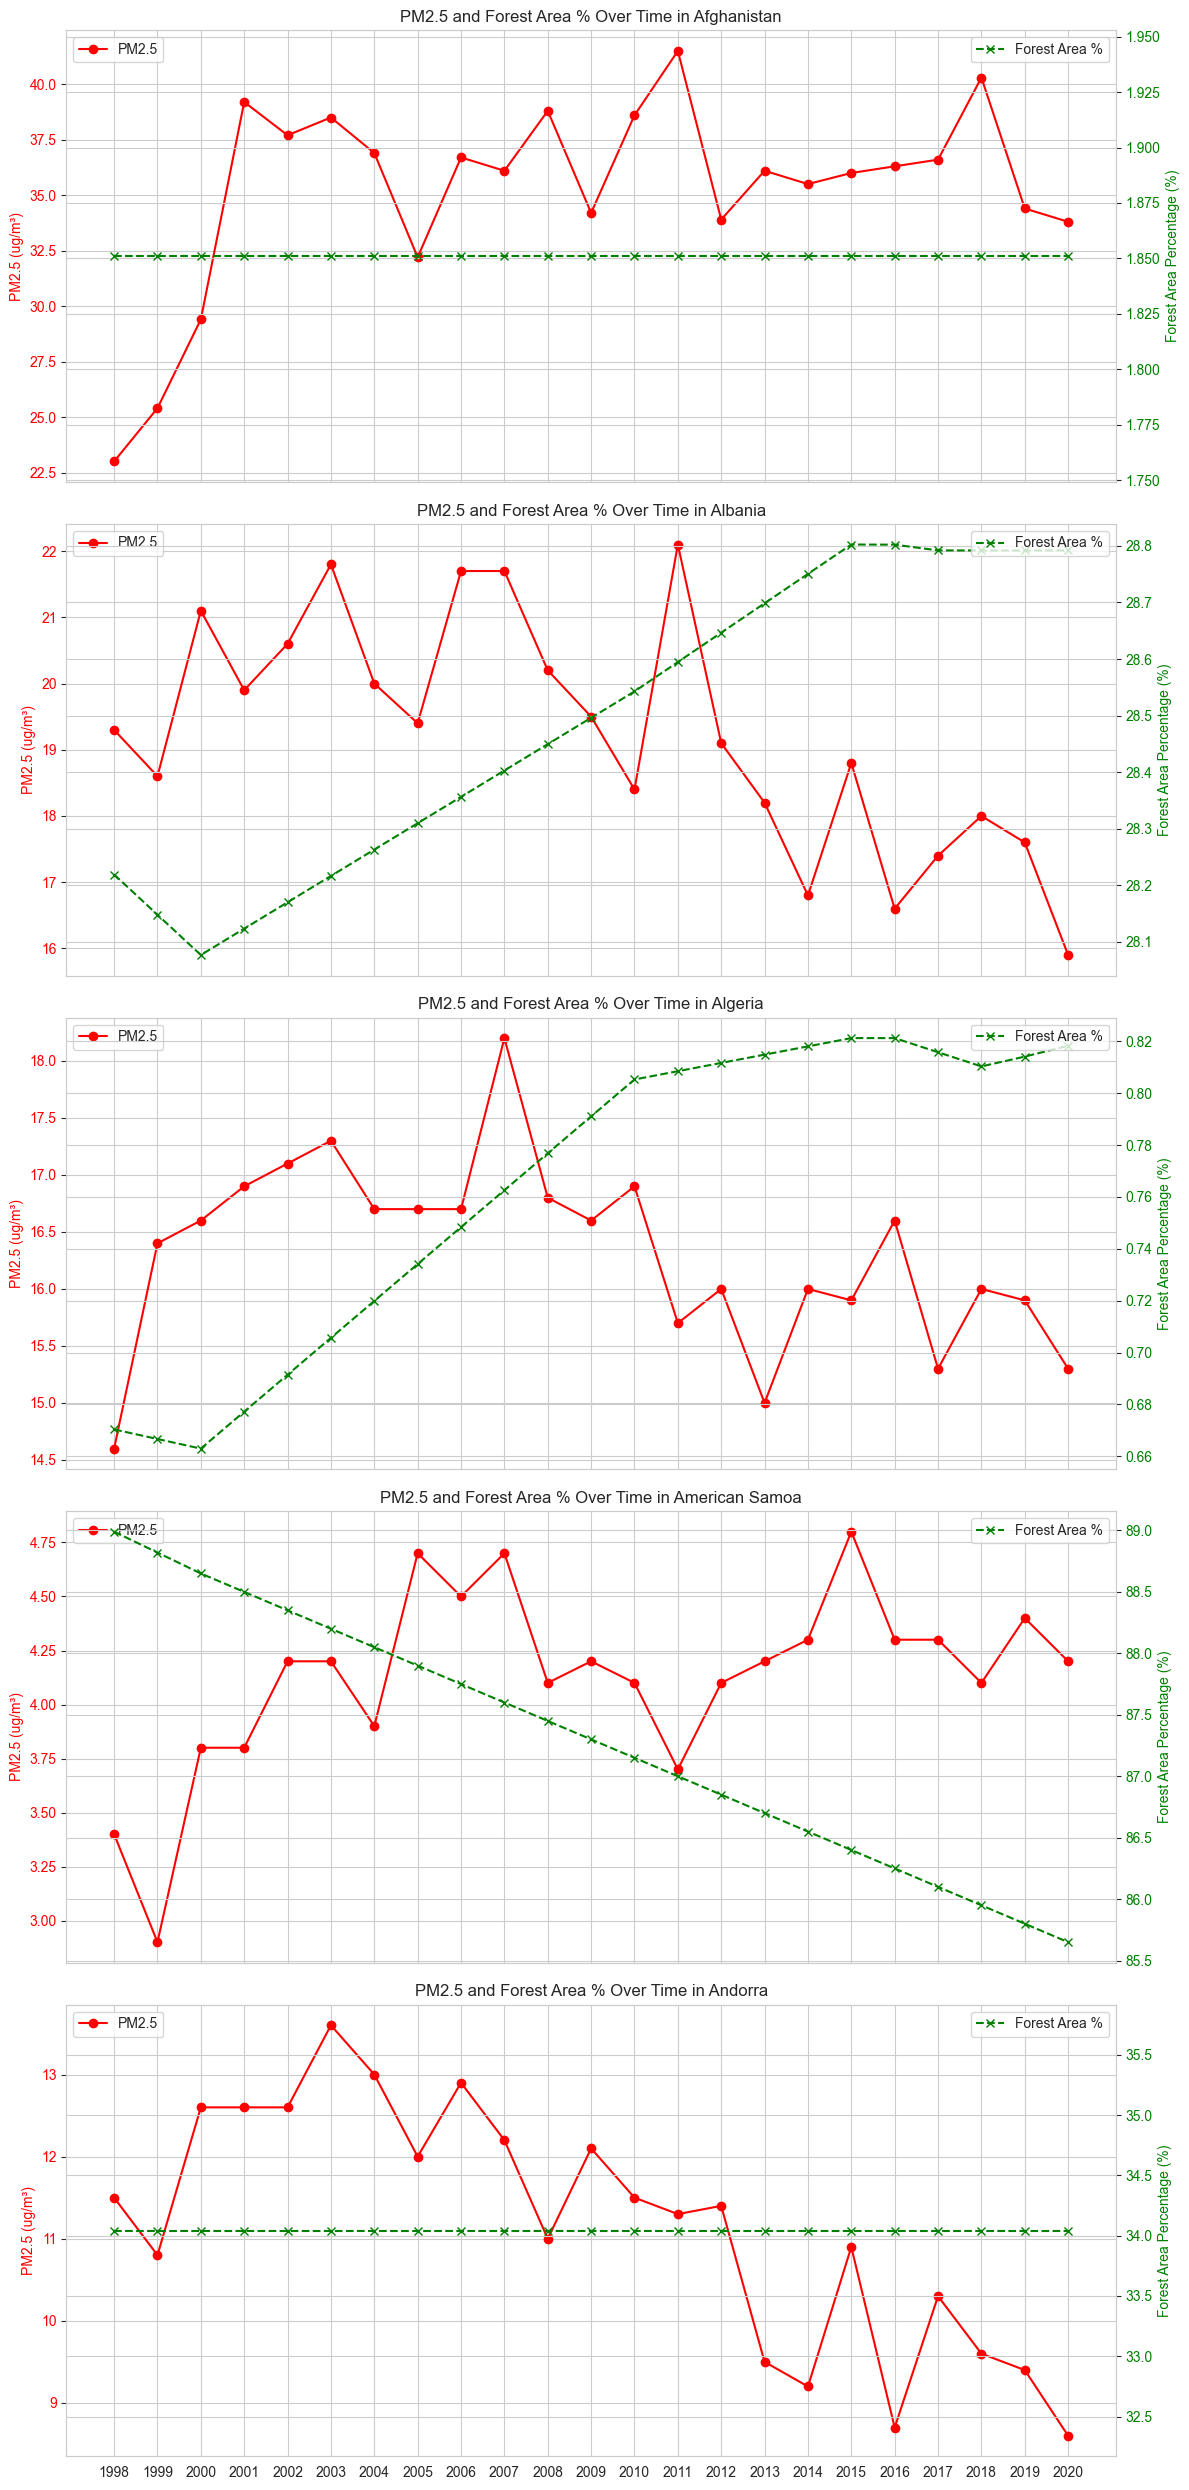

In [326]:
print("\nForest Coverage & PM2.5")

temp_df_h3 = df_analysis.dropna(subset=['forest_area_percent', 'PM25_ug_m3'])
if temp_df_h3.empty:
    print("WARNING: No common data points for forest coverage analysis after dropping NaNs for Hypothesis 3. Skipping this analysis.")
else:
    # 1. Correlation Analysis
    correlation_h3, p_value_h3 = pearsonr(temp_df_h3['forest_area_percent'], temp_df_h3['PM25_ug_m3'])
    print(f"Pearson correlation between Forest Area Percent and PM2.5: {correlation_h3:.2f} (p-value: {p_value_h3:.3f})")

    # 2. Scatter Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='forest_area_percent', y='PM25_ug_m3', hue='continent', data=temp_df_h3, s=100, alpha=0.7)
    plt.title('PM2.5 vs. Forest Area Percentage, by Continent')
    plt.xlabel('Forest Area Percentage (%)')
    plt.ylabel('PM2.5 (ug/m³)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Continent')
    plt.show()

    # 3. Line Plot (Time Series) for selected countries 
    # Filter for countries with more than one year of data to show trends
    countries_with_multiple_years = temp_df_h3.groupby('Country')['Year'].nunique()
    selected_countries_for_time_series = countries_with_multiple_years[countries_with_multiple_years > 1].index.tolist()

    if selected_countries_for_time_series:
        # Limit to top 4-5 countries for readability if many have multiple years
        selected_countries_for_time_series = selected_countries_for_time_series[:5]
        df_time_series = temp_df_h3[temp_df_h3['Country'].isin(selected_countries_for_time_series)].sort_values(by=['Country', 'Year'])

        if not df_time_series.empty:
            fig, axes = plt.subplots(len(selected_countries_for_time_series), 1, figsize=(12, 5 * len(selected_countries_for_time_series)), sharex=True)
            if len(selected_countries_for_time_series) == 1:
                axes = [axes]

            for i, country in enumerate(selected_countries_for_time_series):
                ax1 = axes[i]
                country_data = df_time_series[df_time_series['Country'] == country]

                ax1.plot(country_data['Year'], country_data['PM25_ug_m3'], color='red', marker='o', label='PM2.5')
                ax1.set_ylabel('PM2.5 (ug/m³)', color='red')
                ax1.tick_params(axis='y', labelcolor='red')

                ax2 = ax1.twinx() # Create a secondary y-axis
                ax2.plot(country_data['Year'], country_data['forest_area_percent'], color='green', marker='x', linestyle='--', label='Forest Area %')
                ax2.set_ylabel('Forest Area Percentage (%)', color='green')
                ax2.tick_params(axis='y', labelcolor='green')

                ax1.set_title(f'PM2.5 and Forest Area % Over Time in {country}')
                fig.tight_layout()
                ax1.legend(loc='upper left')
                ax2.legend(loc='upper right')
            plt.show()
        else:
            print("Not enough data to plot time series for selected countries")
    else:
        print("No countries with multiple years of data found for time series plot.")


### Global Visualization of Average PM2.5 and Forest Area

In [327]:
df_country_avg_h3 = temp_df_h3.groupby('Country').agg(
    PM25_ug_m3=('PM25_ug_m3', 'mean'),
    forest_area_percent=('forest_area_percent', 'mean'),
    continent=('continent', 'first')
    ).reset_index()

if not df_country_avg_h3.empty:
    fig = px.choropleth(df_country_avg_h3,
                        locations="Country",
                        locationmode='country names',
                        color="PM25_ug_m3",
                        hover_name="Country",
                        hover_data={'forest_area_percent': ':.2f', 'PM25_ug_m3': ':.2f'},
                        color_continuous_scale=px.colors.sequential.Viridis,
                        title='Average PM2.5 Across Countries - interactive map',
                        )
    fig.show()
else:
    print("Not enough data to create visualization.")

## Data Analysis on the air_quality_city

In [328]:
df_air_quality_csv = pd.read_csv("filtered data/air_quality_city-standardized.csv")

df_air_quality_csv

,Region,Country,City/Town,Year,"Annual mean, ug/m3"
0,Europe (LMIC),Albania,Korce,2015,30
1,Europe (LMIC),Albania,Korce,2016,29
2,Europe (LMIC),Albania,Tirana,2013,16
3,Europe (LMIC),Albania,Vlore,2014,(10)-converted value
4,Europe (LMIC),Albania,Vlore,2015,(13)-converted value
...,...,...,...,...,...
11957,Africa (Sub-Saharan) (LMIC),South Africa,Tshwane [Pretoria],2014,(51)-converted value
11958,Africa (Sub-Saharan) (LMIC),South Africa,Vereeniging,2014,34
11959,Africa (Sub-Saharan) (LMIC),South Africa,Waterberg,2014,18
11960,Africa (Sub-Saharan) (LMIC),South Africa,Witbank,2014,16


In [329]:
# Load the country capitals from a JSON file
try:
    with open('country_capitals.json', 'r') as f:
        country_capitals = json.load(f)
except FileNotFoundError:
    print("Error: 'country_capitals.json' not found. Please create this file with the country-capital mapping.")
    country_capitals = {}  

if 'Country' in df_air_quality_csv.columns:
    df_air_quality_csv['capital'] = df_air_quality_csv['Country'].map(country_capitals)
else:
    print("Error: 'Country' column not found in the DataFrame.")

# Cleaning the Annual mean, ug/m3 column    
def clean_annual_mean(value):
    if isinstance(value, str):
        match = re.search(r'\((\d+)\)-converted value', value)
        if match:
            return int(match.group(1))
        try:
            return float(value)
        except ValueError:
            return np.nan
    return value

df_air_quality_csv['Annual mean, ug/m3'] = df_air_quality_csv['Annual mean, ug/m3'].apply(clean_annual_mean)

df_air_quality_csv['Annual mean, ug/m3'] = pd.to_numeric(df_air_quality_csv['Annual mean, ug/m3'], errors='coerce')

df_air_quality_csv   

,Region,Country,City/Town,Year,"Annual mean, ug/m3",capital
0,Europe (LMIC),Albania,Korce,2015,30.0,Tirana
1,Europe (LMIC),Albania,Korce,2016,29.0,Tirana
2,Europe (LMIC),Albania,Tirana,2013,16.0,Tirana
3,Europe (LMIC),Albania,Vlore,2014,10.0,Tirana
4,Europe (LMIC),Albania,Vlore,2015,13.0,Tirana
...,...,...,...,...,...,...
11957,Africa (Sub-Saharan) (LMIC),South Africa,Tshwane [Pretoria],2014,51.0,Pretoria
11958,Africa (Sub-Saharan) (LMIC),South Africa,Vereeniging,2014,34.0,Pretoria
11959,Africa (Sub-Saharan) (LMIC),South Africa,Waterberg,2014,18.0,Pretoria
11960,Africa (Sub-Saharan) (LMIC),South Africa,Witbank,2014,16.0,Pretoria


### Analysis of the difference between the capital of a country and the other cities

In [330]:
# Separate Capital Cities and Calculate Average PM2.5 by Capital
df_capital_avg = df_air_quality_csv[df_air_quality_csv['City/Town'] == df_air_quality_csv['capital']].copy()
df_capital_avg = df_capital_avg.groupby(['Country', 'capital'])['Annual mean, ug/m3'].mean().reset_index(name='Avg_PM2.5_Capital')

# Separate Other Cities and Calculate Average PM2.5 by Country
df_other_cities = df_air_quality_csv[df_air_quality_csv['City/Town'] != df_air_quality_csv['capital']].copy()
df_other_cities_avg = df_other_cities.groupby('Country')['Annual mean, ug/m3'].mean().reset_index(name='Avg_PM2.5_Other_Cities')

# Merge
df_comparison_avg = pd.merge(df_capital_avg,
                             df_other_cities_avg,
                             on='Country',
                             how='left')

df_comparison_avg['Diff'] = df_comparison_avg['Avg_PM2.5_Capital'] - df_comparison_avg['Avg_PM2.5_Other_Cities']
df_comparison_avg['Percent_Diff'] = (df_comparison_avg['Diff'] / df_comparison_avg['Avg_PM2.5_Other_Cities']) * 100

df_comparison_avg

,Country,capital,Avg_PM2.5_Capital,Avg_PM2.5_Other_Cities,Diff,Percent_Diff
0,Albania,Tirana,16.00,18.333333,-2.333333,-12.727273
1,Argentina,Buenos Aires,12.00,NaN,NaN,NaN
2,Australia,Canberra,6.80,7.590551,-0.790551,-10.414938
3,Bahrain,Manama,63.00,54.600000,8.400000,15.384615
4,Bangladesh,Dhaka,77.50,74.600000,2.900000,3.887399
...,...,...,...,...,...,...
65,Uganda,Kampala,104.00,NaN,NaN,NaN
66,Ukraine,Kyiv,22.00,NaN,NaN,NaN
67,United Arab Emirates,Abu Dhabi,59.60,55.769231,3.830769,6.868966
68,United Kingdom,London,13.25,10.822134,2.427866,22.434259


In [331]:
df_comparison_avg_sorted = df_comparison_avg.sort_values('Diff')

fig = px.scatter(
    df_comparison_avg_sorted,
    x='Diff',
    y='Country',
    title='Difference in PM2.5 (Capital - Other Cities)'
)

fig.update_layout(xaxis_title='Difference (Capital - Other Cities)', yaxis_title='Country')
iplot(fig)

## Data Analysis on the Global Weather Repository

In [332]:
df_weather_csv = pd.read_csv("filtered data/GlobalWeatherRepository-standardized.csv")

df_weather_csv

,Country,location_name,latitude,longitude,last_updated,temperature_celsius,precip_mm,humidity,air_quality_PM2.5,air_quality_PM10
0,Afghanistan,Kabul,34.52,69.18,2023/8/29 14:00,28.8,0.00,19,7.9,11.1
1,Albania,Tirana,41.33,19.82,2023/8/29 11:30,27.0,0.00,54,28.2,29.6
2,Algeria,Algiers,36.76,3.05,2023/8/29 10:30,28.0,0.00,30,6.4,7.9
3,Andorra,Andorra La Vella,42.50,1.52,2023/8/29 11:30,10.2,0.00,51,0.5,0.8
4,Angola,Luanda,-8.84,13.23,2023/8/29 10:30,25.0,0.00,69,139.6,203.3
...,...,...,...,...,...,...,...,...,...,...
40536,Venezuela,Caracas,10.50,-66.92,2024/3/28 12:00,28.3,0.00,39,1.9,3.2
40537,Vietnam,Hanoi,21.03,105.85,2024/3/28 23:00,25.0,0.00,94,78.6,93.7
40538,Yemen,Sanaa,15.35,44.21,2024/3/28 19:00,19.6,0.45,51,5.5,11.9
40539,Zambia,Lusaka,-15.42,28.28,2024/3/28 18:00,25.0,0.00,58,13.0,23.0


Correlation Matrix:
                      temperature_celsius  precip_mm  humidity  \
temperature_celsius             1.000000   0.036890 -0.292174   
precip_mm                       0.036890   1.000000  0.147772   
humidity                       -0.292174   0.147772  1.000000   
air_quality_PM2.5               0.020876  -0.036343 -0.049502   
air_quality_PM10                0.106422  -0.049248 -0.180899   

                     air_quality_PM2.5  air_quality_PM10  
temperature_celsius           0.020876          0.106422  
precip_mm                    -0.036343         -0.049248  
humidity                     -0.049502         -0.180899  
air_quality_PM2.5             1.000000          0.864159  
air_quality_PM10              0.864159          1.000000  


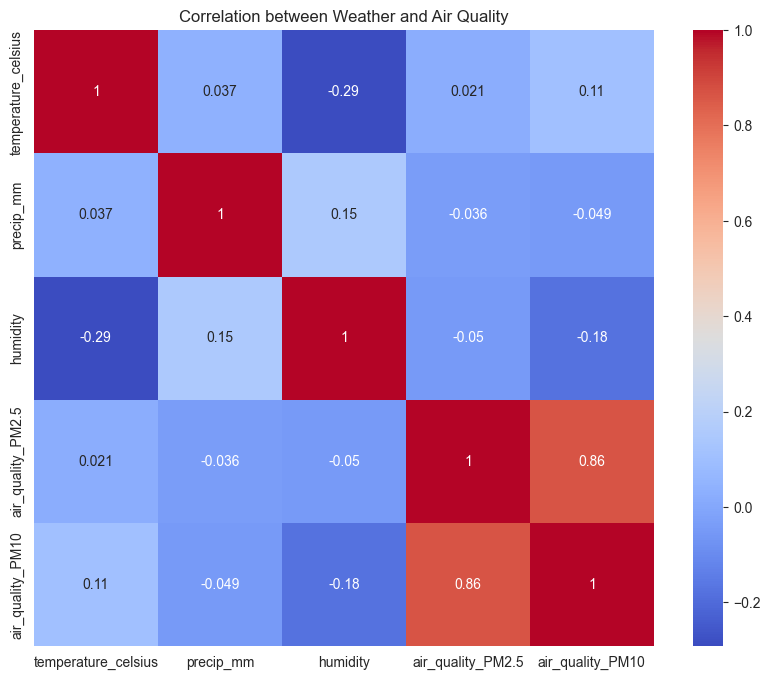

In [333]:
# Correlation analysis
correlation_matrix = df_weather_csv[['temperature_celsius', 'precip_mm', 'humidity', 'air_quality_PM2.5', 'air_quality_PM10']].corr()
print("Correlation Matrix:\n", correlation_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Weather and Air Quality')
plt.show()


### Time Series analysis between PM2.5 and Temperature

In [334]:
# Convert 'last_updated' to datetime
df_weather_csv['last_updated'] = pd.to_datetime(df_weather_csv['last_updated'])

# Aggregate Data 
df_daily = df_weather_csv.groupby(df_weather_csv['last_updated'].dt.date).agg({
    'air_quality_PM2.5': 'mean',
    'temperature_celsius': 'mean'
}).reset_index()
df_daily['last_updated'] = pd.to_datetime(df_daily['last_updated'])  

fig = go.Figure()

# PM2.5 trace
fig.add_trace(go.Scatter(
    x=df_daily['last_updated'],
    y=df_daily['air_quality_PM2.5'],
    name='PM2.5',
    yaxis='y1'
))

# Temperature trace
fig.add_trace(go.Scatter(
    x=df_daily['last_updated'],
    y=df_daily['temperature_celsius'],
    name='Temperature',
    yaxis='y2'
))

fig.update_layout(
    title='PM2.5 and Temperature Over Time',
    xaxis_title='Date',
    yaxis=dict(
        title='PM2.5 (ug/m3)',
        side='left'
    ),
    yaxis2=dict(
        title='Temperature (°C)',
        side='right',
        overlaying='y', 
        position=1
    )
)

iplot(fig)